# Model Evaluation
Run `test_all.sh` to generate the evaluation metrics for all models.

In [ ]:
!bash test_all.sh

## Compare Accuracies
Plot the Character Error Rate (CER) and Word Error Rate (WER) across all models.

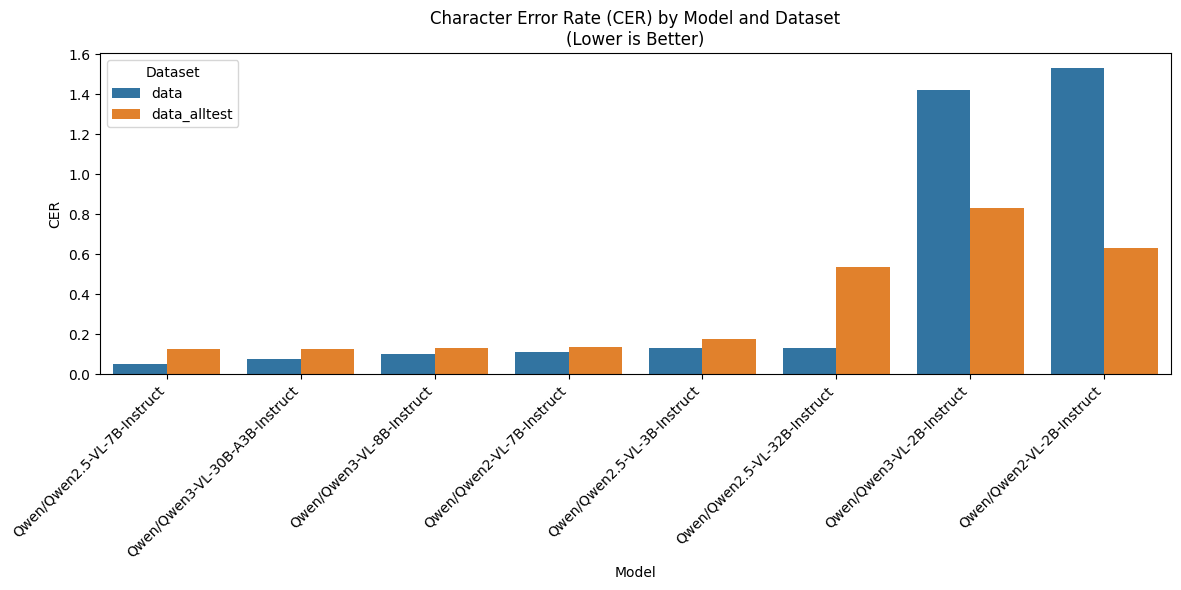

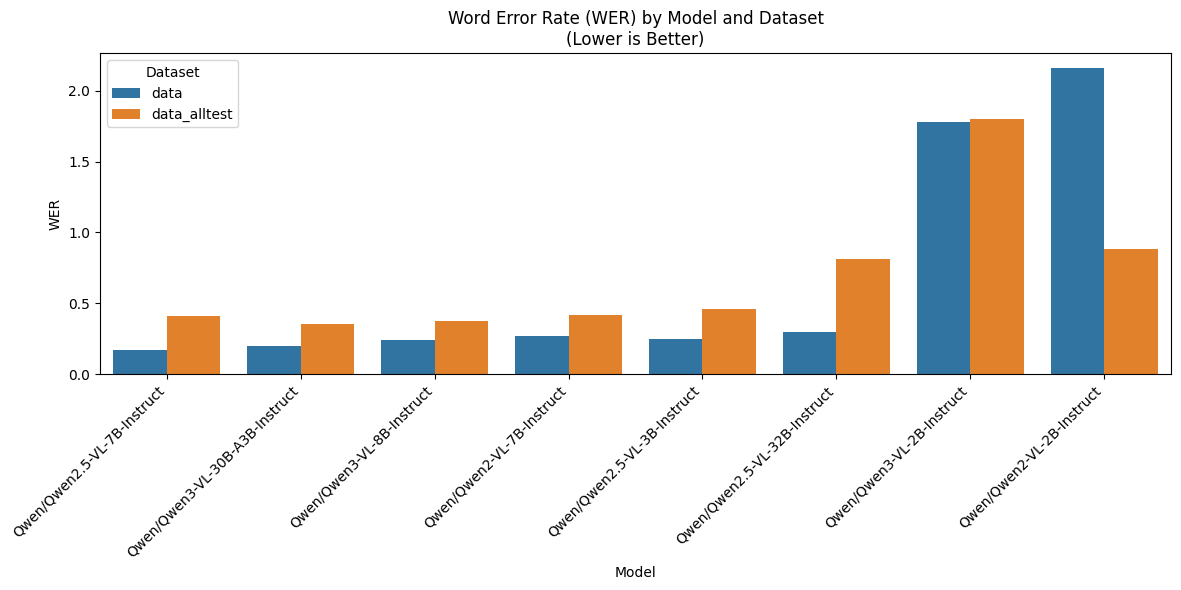

In [4]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

outputs_dir = 'outputs'
results = []

# Read all json output files
if os.path.exists(outputs_dir):
    for filename in os.listdir(outputs_dir):
        if filename.endswith('.json'):
            filepath = os.path.join(outputs_dir, filename)
            with open(filepath, 'r') as f:
                try:
                    data = json.load(f)
                    results.append({
                        'Model': data.get('model_id', 'Unknown'),
                        'Dataset': data.get('data_dir', 'Unknown'),
                        'CER': data.get('cer', None),
                        'WER': data.get('wer', None)
                    })
                except json.JSONDecodeError:
                    print(f"Warning: Could not parse {filename}")

df = pd.DataFrame(results)
df = df.sort_values(by=['Dataset', 'CER']).reset_index(drop=True)

if not df.empty:
    # Accuracy is typically inversely related to CER and WER. Lower CER/WER = Higher Accuracy.
    # Here, we plot both CER and WER where lower scores indicate better performance.
    
    def plot_metric(metric, title):
        plt.figure(figsize=(12, 6))
        sns.barplot(data=df, x='Model', y=metric, hue='Dataset')
        plt.title(title)
        plt.xticks(rotation=45, ha='right')
        plt.ylabel(metric)
        plt.tight_layout()
        plt.show()

    plot_metric('CER', 'Character Error Rate (CER) by Model and Dataset\n(Lower is Better)')
    plot_metric('WER', 'Word Error Rate (WER) by Model and Dataset\n(Lower is Better)')
else:
    print("No evaluation results found in the 'outputs' directory.")
